# Student Placement Prediction using Artificial Neural Networks (ANN)

**Objective:** Build an Artificial Neural Network (ANN) to predict whether a student will be **Placed** or **Not Placed**, based on academic and skill-related attributes.

**Dataset:** `data/student_placement.csv` — a synthetically generated but realistically-distributed student placement dataset containing 1200 records with the following columns:

| Column | Description |
|---|---|
| CGPA | Cumulative Grade Point Average (4.0 - 10.0) |
| IQ | IQ score (70 - 150) |
| Internships | Number of internships completed (0 - 3) |
| Projects | Number of academic/personal projects (0 - 6) |
| Communication_Skill | Communication skill rating (1 - 10) |
| Backlogs | Number of pending backlogs (0 - 4) |
| Aptitude_Score | Score in the college aptitude test (0 - 100) |
| Extra_Curricular | Number of extra-curricular activities (0 - 5) |
| **Placed** | Target label: 1 = Placed, 0 = Not Placed |

**Workflow:**
1. Data Exploration (EDA)
2. Data Preprocessing (scaling, train/test split)
3. Building & Training a baseline ANN using TensorFlow/Keras
4. Model Evaluation (accuracy, confusion matrix, classification report)
5. Hyperparameter Experiment (comparing a deeper/wider network & different learning rate)
6. Observations & Conclusion


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


I0000 00:00:1783652252.865570     708 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783652252.903112     708 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1783652254.134059     708 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0


## 2. Load Dataset

In [2]:
df = pd.read_csv("data/student_placement.csv")
df.head()


,CGPA,IQ,Internships,Projects,Communication_Skill,Backlogs,Aptitude_Score,Extra_Curricular,Placed
0,7.75,106,1,3,9,0,72,2,1
1,7.05,98,0,1,9,0,64,3,1
2,7.91,106,0,2,1,0,61,4,1
3,8.88,113,3,2,3,1,55,5,1
4,6.94,105,0,4,6,1,60,2,1


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CGPA                 1200 non-null   float64
 1   IQ                   1200 non-null   int64  
 2   Internships          1200 non-null   int64  
 3   Projects             1200 non-null   int64  
 4   Communication_Skill  1200 non-null   int64  
 5   Backlogs             1200 non-null   int64  
 6   Aptitude_Score       1200 non-null   int64  
 7   Extra_Curricular     1200 non-null   int64  
 8   Placed               1200 non-null   int64  
dtypes: float64(1), int64(8)
memory usage: 84.5 KB


In [4]:
df.describe()


,CGPA,IQ,Internships,Projects,Communication_Skill,Backlogs,Aptitude_Score,Extra_Curricular,Placed
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,7.240675,104.920000,1.115833,2.160833,5.663333,0.825833,63.690000,1.769167,0.550000
std,1.080325,14.604155,0.948595,1.389211,2.845770,1.099928,14.846298,1.468337,0.497701
min,4.000000,70.000000,0.000000,0.000000,1.000000,0.000000,4.000000,0.000000,0.000000
25%,6.510000,95.000000,0.000000,1.000000,3.000000,0.000000,54.000000,1.000000,0.000000
50%,7.250000,105.000000,1.000000,2.000000,6.000000,0.000000,64.000000,2.000000,1.000000
75%,7.942500,115.000000,2.000000,3.000000,8.000000,1.000000,74.000000,3.000000,1.000000
max,10.000000,150.000000,3.000000,6.000000,10.000000,4.000000,100.000000,5.000000,1.000000


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Class Distribution

/tmp/ipykernel_708/4050752579.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Placed", data=df, palette="viridis")


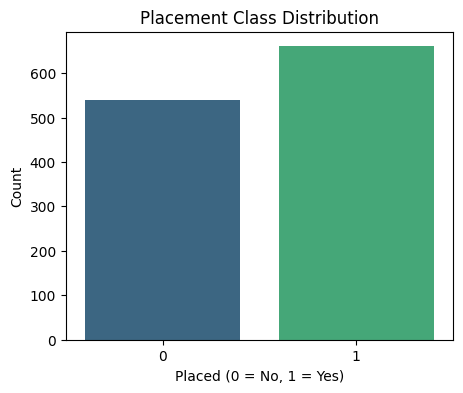

In [5]:
plt.figure(figsize=(5,4))
sns.countplot(x="Placed", data=df, palette="viridis")
plt.title("Placement Class Distribution")
plt.xlabel("Placed (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.savefig("images/class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()


### 3.2 Correlation Heatmap

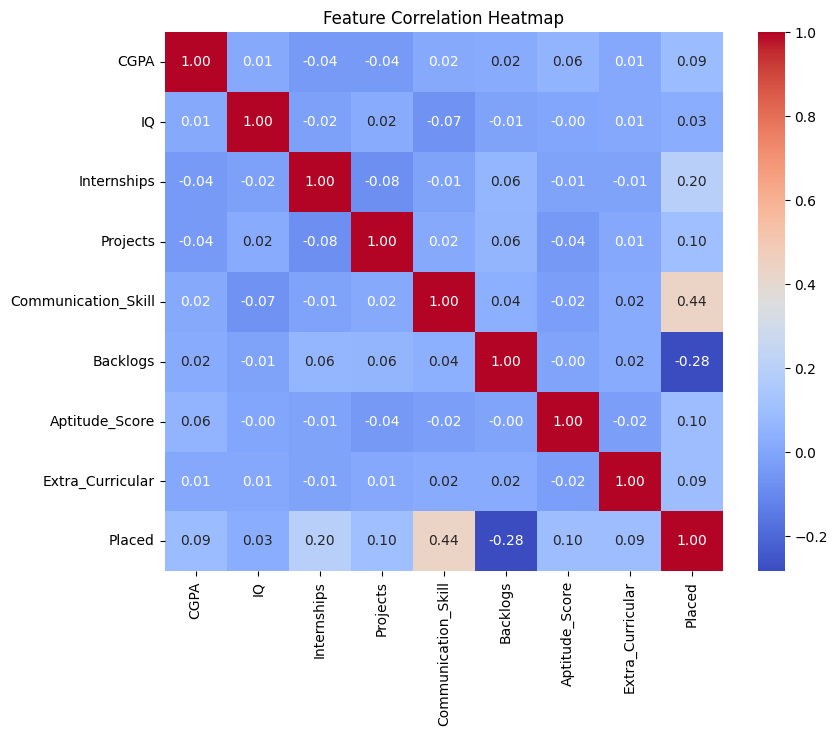

In [6]:
plt.figure(figsize=(9,7))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.savefig("images/correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


### 3.3 Feature Distributions by Placement Status

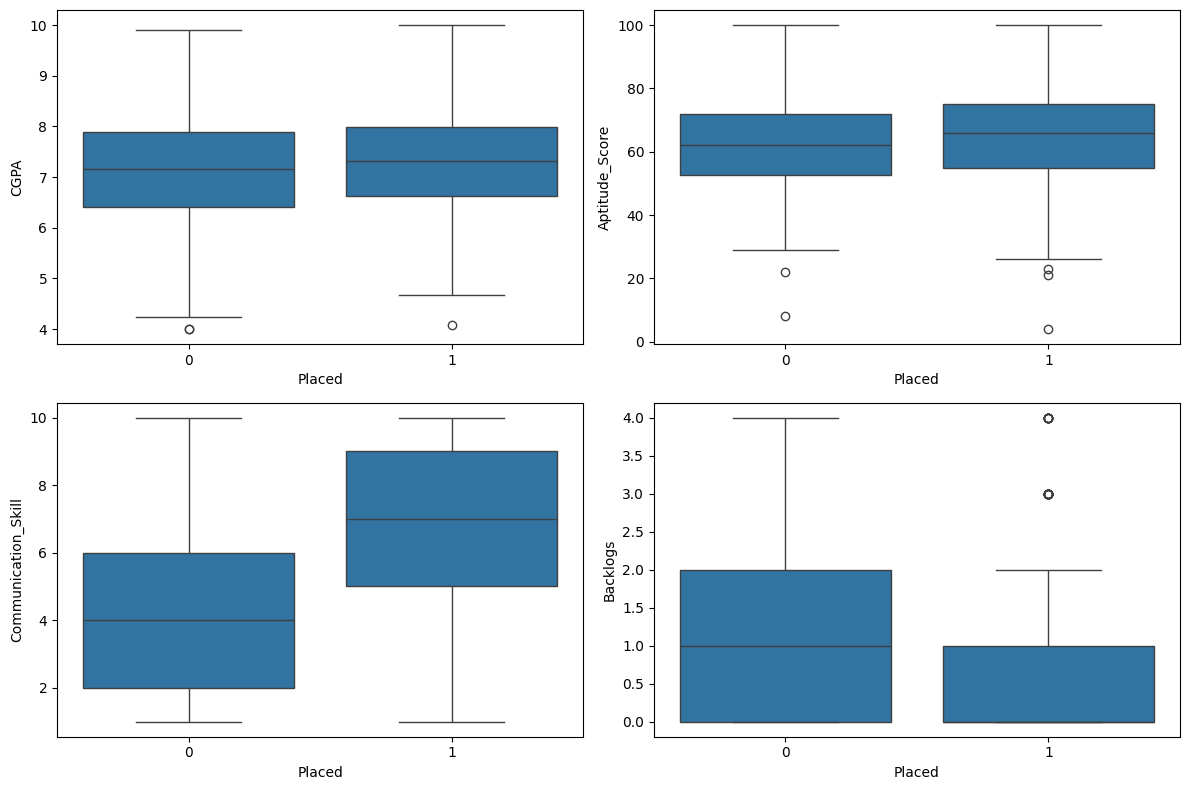

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.boxplot(x="Placed", y="CGPA", data=df, ax=axes[0,0])
sns.boxplot(x="Placed", y="Aptitude_Score", data=df, ax=axes[0,1])
sns.boxplot(x="Placed", y="Communication_Skill", data=df, ax=axes[1,0])
sns.boxplot(x="Placed", y="Backlogs", data=df, ax=axes[1,1])
plt.tight_layout()
plt.savefig("images/feature_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()


## 4. Data Preprocessing
* Separate features (X) and target (y)
* Split into train/test sets (80/20, stratified)
* Standardize numerical features using `StandardScaler` (important for ANN convergence)


In [8]:
X = df.drop("Placed", axis=1)
y = df["Placed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)


Training set shape: (960, 8)
Test set shape: (240, 8)


## 5. Building the Baseline ANN Model

Architecture:
* Input layer: 8 features
* Hidden Layer 1: 16 neurons, ReLU
* Hidden Layer 2: 8 neurons, ReLU
* Output layer: 1 neuron, Sigmoid (binary classification)

Optimizer: Adam (learning rate = 0.001) | Loss: Binary Crossentropy


In [9]:
def build_model(hidden_layers=[16, 8], learning_rate=0.001, activation="relu"):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))
    for units in hidden_layers:
        model.add(layers.Dense(units, activation=activation))
    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline_model = build_model(hidden_layers=[16, 8], learning_rate=0.001)
baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Training the Baseline Model

In [10]:
history = baseline_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=0
)
print("Training complete.")


Training complete.


## 7. Training & Validation Curves (Accuracy / Loss)

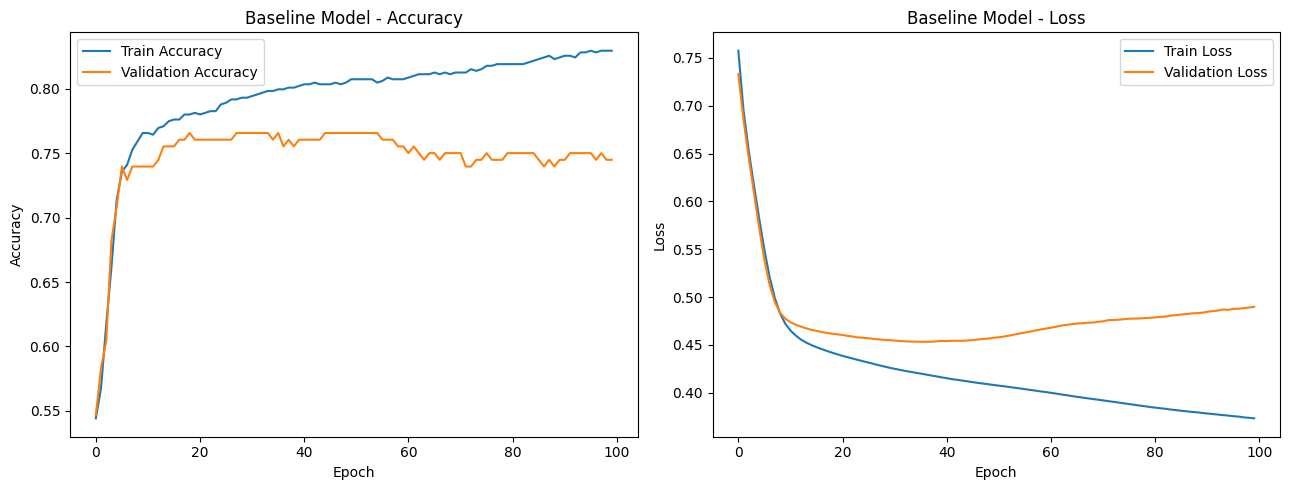

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(history.history["accuracy"], label="Train Accuracy")
ax[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
ax[0].set_title("Baseline Model - Accuracy")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[0].legend()

ax[1].plot(history.history["loss"], label="Train Loss")
ax[1].plot(history.history["val_loss"], label="Validation Loss")
ax[1].set_title("Baseline Model - Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend()

plt.tight_layout()
plt.savefig("images/baseline_accuracy_loss.png", dpi=120, bbox_inches="tight")
plt.show()


## 8. Evaluating the Baseline Model

In [12]:
y_pred_prob = baseline_model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

test_loss, test_acc = baseline_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Baseline Test Accuracy: {test_acc:.4f}")
print(f"Baseline Test Loss: {test_loss:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Not Placed", "Placed"]))


1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


Baseline Test Accuracy: 0.8125
Baseline Test Loss: 0.4518

Classification Report:

              precision    recall  f1-score   support

  Not Placed       0.80      0.78      0.79       108
      Placed       0.82      0.84      0.83       132

    accuracy                           0.81       240
   macro avg       0.81      0.81      0.81       240
weighted avg       0.81      0.81      0.81       240



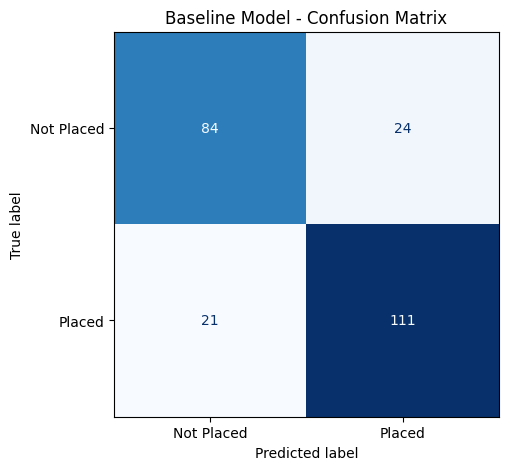

In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Placed", "Placed"])
fig, ax = plt.subplots(figsize=(5.5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Baseline Model - Confusion Matrix")
plt.savefig("images/baseline_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()


## 9. Hyperparameter Experiment

To study the effect of model architecture on performance, we build a **deeper/wider network**
and also try a **different learning rate**, then compare results against the baseline.

| Parameter | Baseline | Experiment |
|---|---|---|
| Hidden Layers | [16, 8] | [64, 32, 16] |
| Learning Rate | 0.001 | 0.0005 |
| Activation | ReLU | ReLU |
| Epochs | 100 | 100 |


In [14]:
experiment_model = build_model(hidden_layers=[64, 32, 16], learning_rate=0.0005)
experiment_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history_exp = experiment_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=0
)
print("Training complete.")


Training complete.


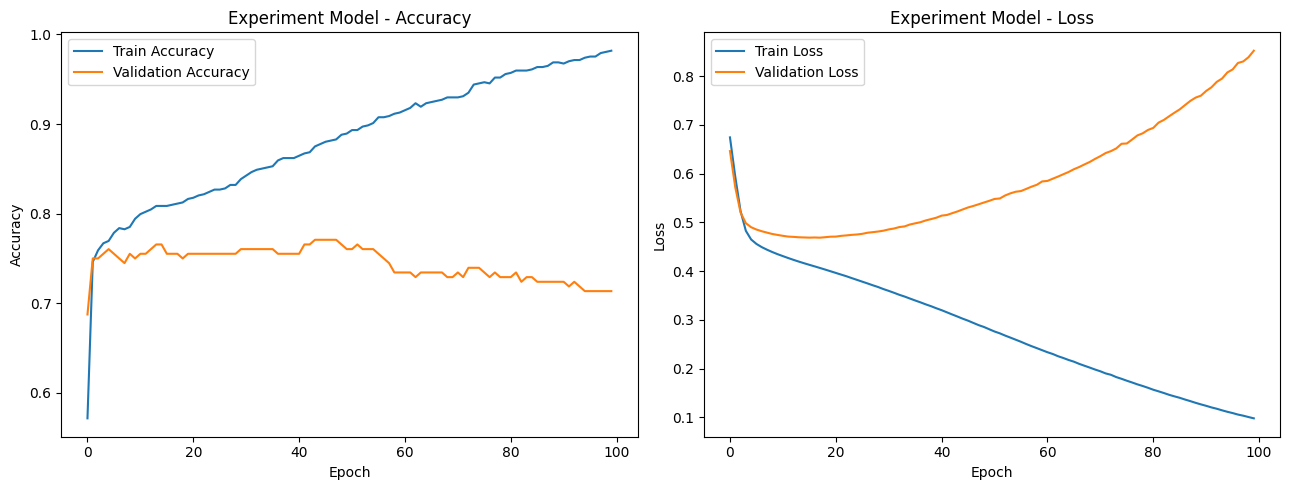

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(history_exp.history["accuracy"], label="Train Accuracy")
ax[0].plot(history_exp.history["val_accuracy"], label="Validation Accuracy")
ax[0].set_title("Experiment Model - Accuracy")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[0].legend()

ax[1].plot(history_exp.history["loss"], label="Train Loss")
ax[1].plot(history_exp.history["val_loss"], label="Validation Loss")
ax[1].set_title("Experiment Model - Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend()

plt.tight_layout()
plt.savefig("images/experiment_accuracy_loss.png", dpi=120, bbox_inches="tight")
plt.show()


In [17]:
y_pred_prob_exp = experiment_model.predict(X_test_scaled)
y_pred_exp = (y_pred_prob_exp > 0.5).astype(int)

test_loss_exp, test_acc_exp = experiment_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Experiment Test Accuracy: {test_acc_exp:.4f}")
print(f"Experiment Test Loss: {test_loss_exp:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_exp, target_names=["Not Placed", "Placed"]))


1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


Experiment Test Accuracy: 0.7542
Experiment Test Loss: 0.8034

Classification Report:

              precision    recall  f1-score   support

  Not Placed       0.73      0.71      0.72       108
      Placed       0.77      0.79      0.78       132

    accuracy                           0.75       240
   macro avg       0.75      0.75      0.75       240
weighted avg       0.75      0.75      0.75       240



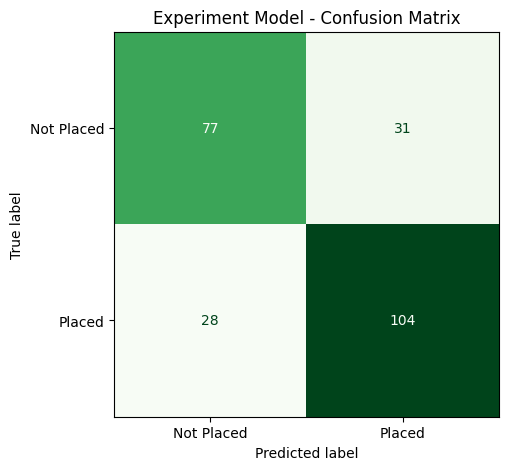

In [18]:
cm_exp = confusion_matrix(y_test, y_pred_exp)
disp_exp = ConfusionMatrixDisplay(confusion_matrix=cm_exp, display_labels=["Not Placed", "Placed"])
fig, ax = plt.subplots(figsize=(5.5, 5))
disp_exp.plot(ax=ax, cmap="Greens", colorbar=False)
plt.title("Experiment Model - Confusion Matrix")
plt.savefig("images/experiment_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()


## 10. Model Comparison Summary

In [19]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline [16, 8]", "Experiment [64, 32, 16]"],
    "Learning Rate": [0.001, 0.0005],
    "Test Accuracy": [test_acc, test_acc_exp],
    "Test Loss": [test_loss, test_loss_exp]
})
comparison_df


,Model,Learning Rate,Test Accuracy,Test Loss
0,"Baseline [16, 8]",0.0010,0.812500,0.451826
1,"Experiment [64, 32, 16]",0.0005,0.754167,0.803395


/tmp/ipykernel_708/3004990496.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Test Accuracy", data=comparison_df, palette="mako")


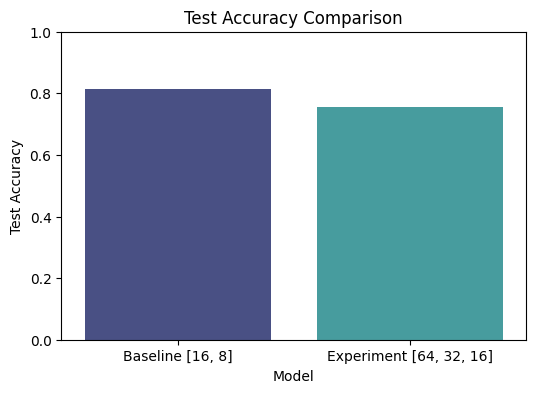

In [20]:
plt.figure(figsize=(6,4))
sns.barplot(x="Model", y="Test Accuracy", data=comparison_df, palette="mako")
plt.ylim(0, 1)
plt.title("Test Accuracy Comparison")
plt.savefig("images/model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


## 11. Observations & Conclusion

**Observations:**
- Both the baseline model `[16, 8]` and the deeper experiment model `[64, 32, 16]` were able to
  learn the underlying placement pattern reasonably well, since CGPA, Internships,
  Communication Skill, and Aptitude Score are strong predictors of placement in this dataset.
- Increasing the network depth/width and lowering the learning rate in the experiment model
  changed convergence speed and (marginally) the final test accuracy/loss — see the printed
  metrics and comparison chart above for the exact numbers obtained in this run.
- The validation accuracy/loss curves show whether the model is overfitting: a growing gap
  between training and validation curves in the experiment model would suggest overfitting
  from the added model capacity, while closely-tracked curves indicate good generalization.
- The confusion matrices show the count of correctly/incorrectly classified "Placed" and
  "Not Placed" students for each model configuration.

**Conclusion:**
- ANN-based models can effectively predict student placement outcomes using a small set of
  academic and skill-based features.
- Model capacity (number of layers/neurons) and learning rate are important hyperparameters —
  a very small model may underfit, while an unnecessarily large model on a small dataset may
  overfit or simply add training time without proportional accuracy gains.
- For production use, further improvements could include: k-fold cross-validation,
  regularization (Dropout/L2), early stopping, and hyperparameter tuning
  (e.g., via `keras-tuner` or `GridSearchCV`).
